In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN
from bss.PredictiveDecorrBSS import PredictiveDecorrBSS

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -1, max_val = 1)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  1975112
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.998023805880386


(array([0.333599  , 0.33364039, 0.33419157, 0.33375482, 0.33382209]),
 array([1.06072582, 1.65450498, 2.5524147 , 2.90927274, 2.10350649,
        0.18575396, 1.45388665, 1.16883679, 1.94854373, 0.33572335]))

# Hyperparameters

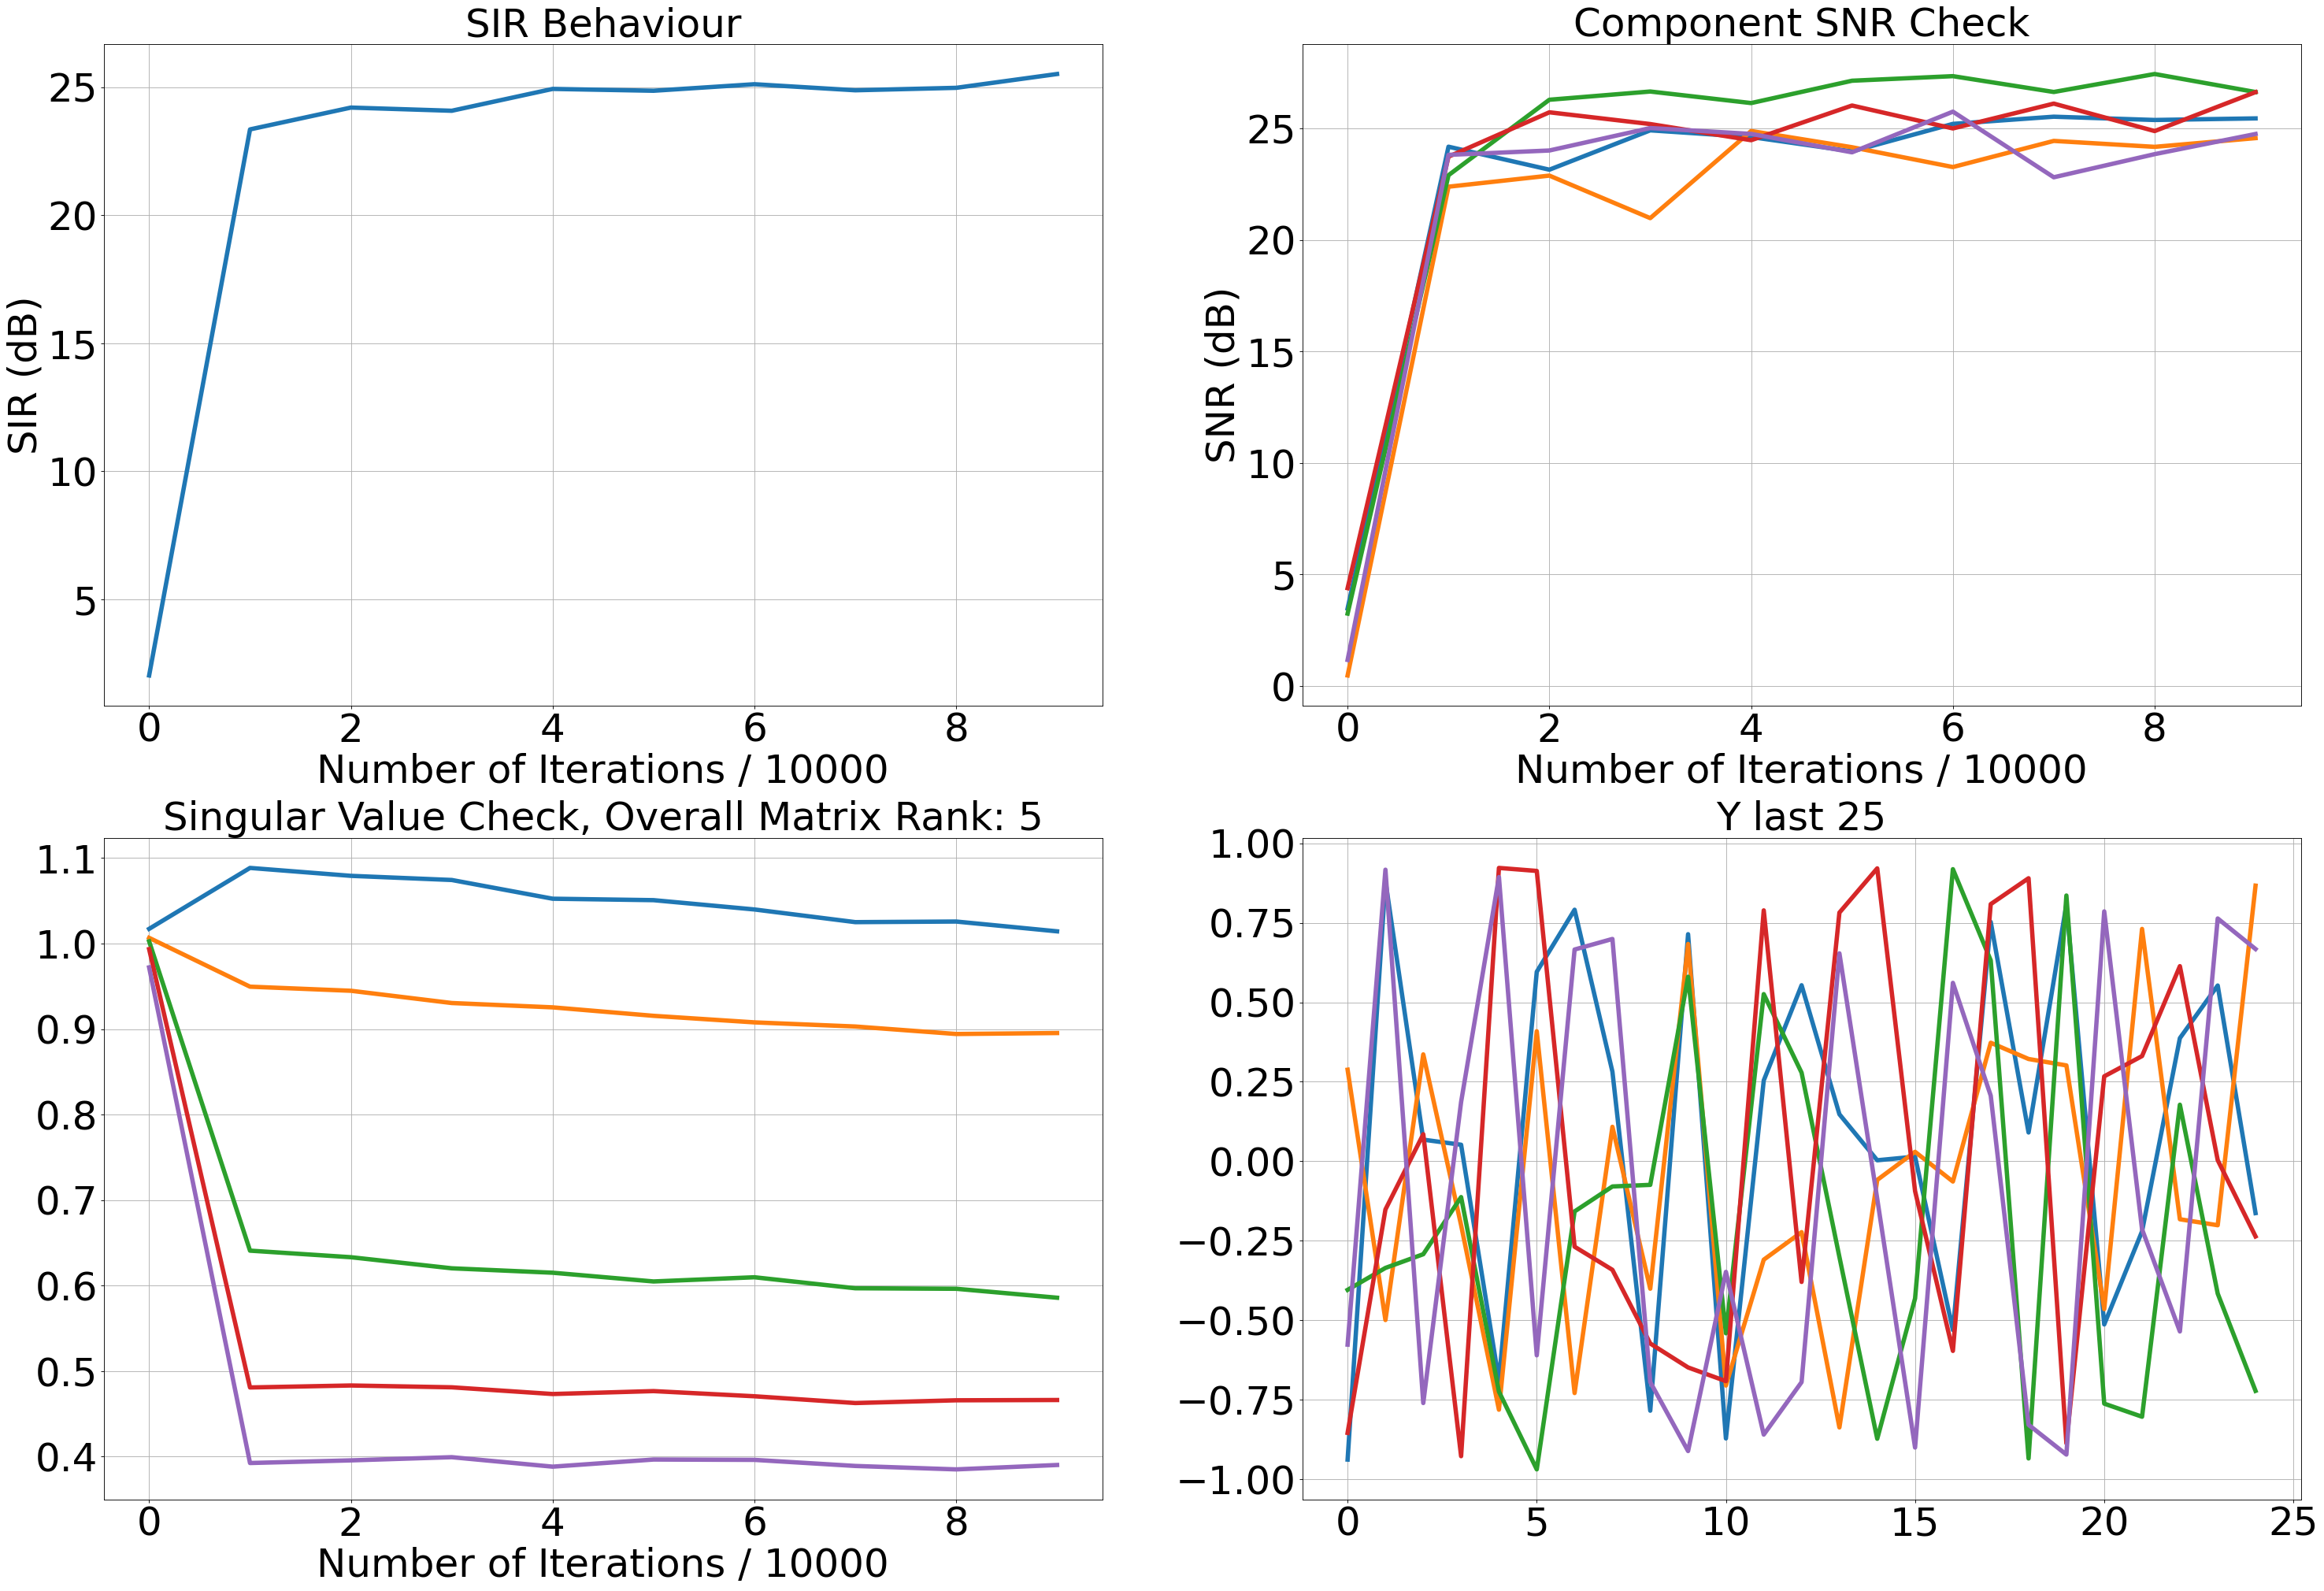

100%|██████████| 100000/100000 [00:24<00:00, 4155.14it/s]


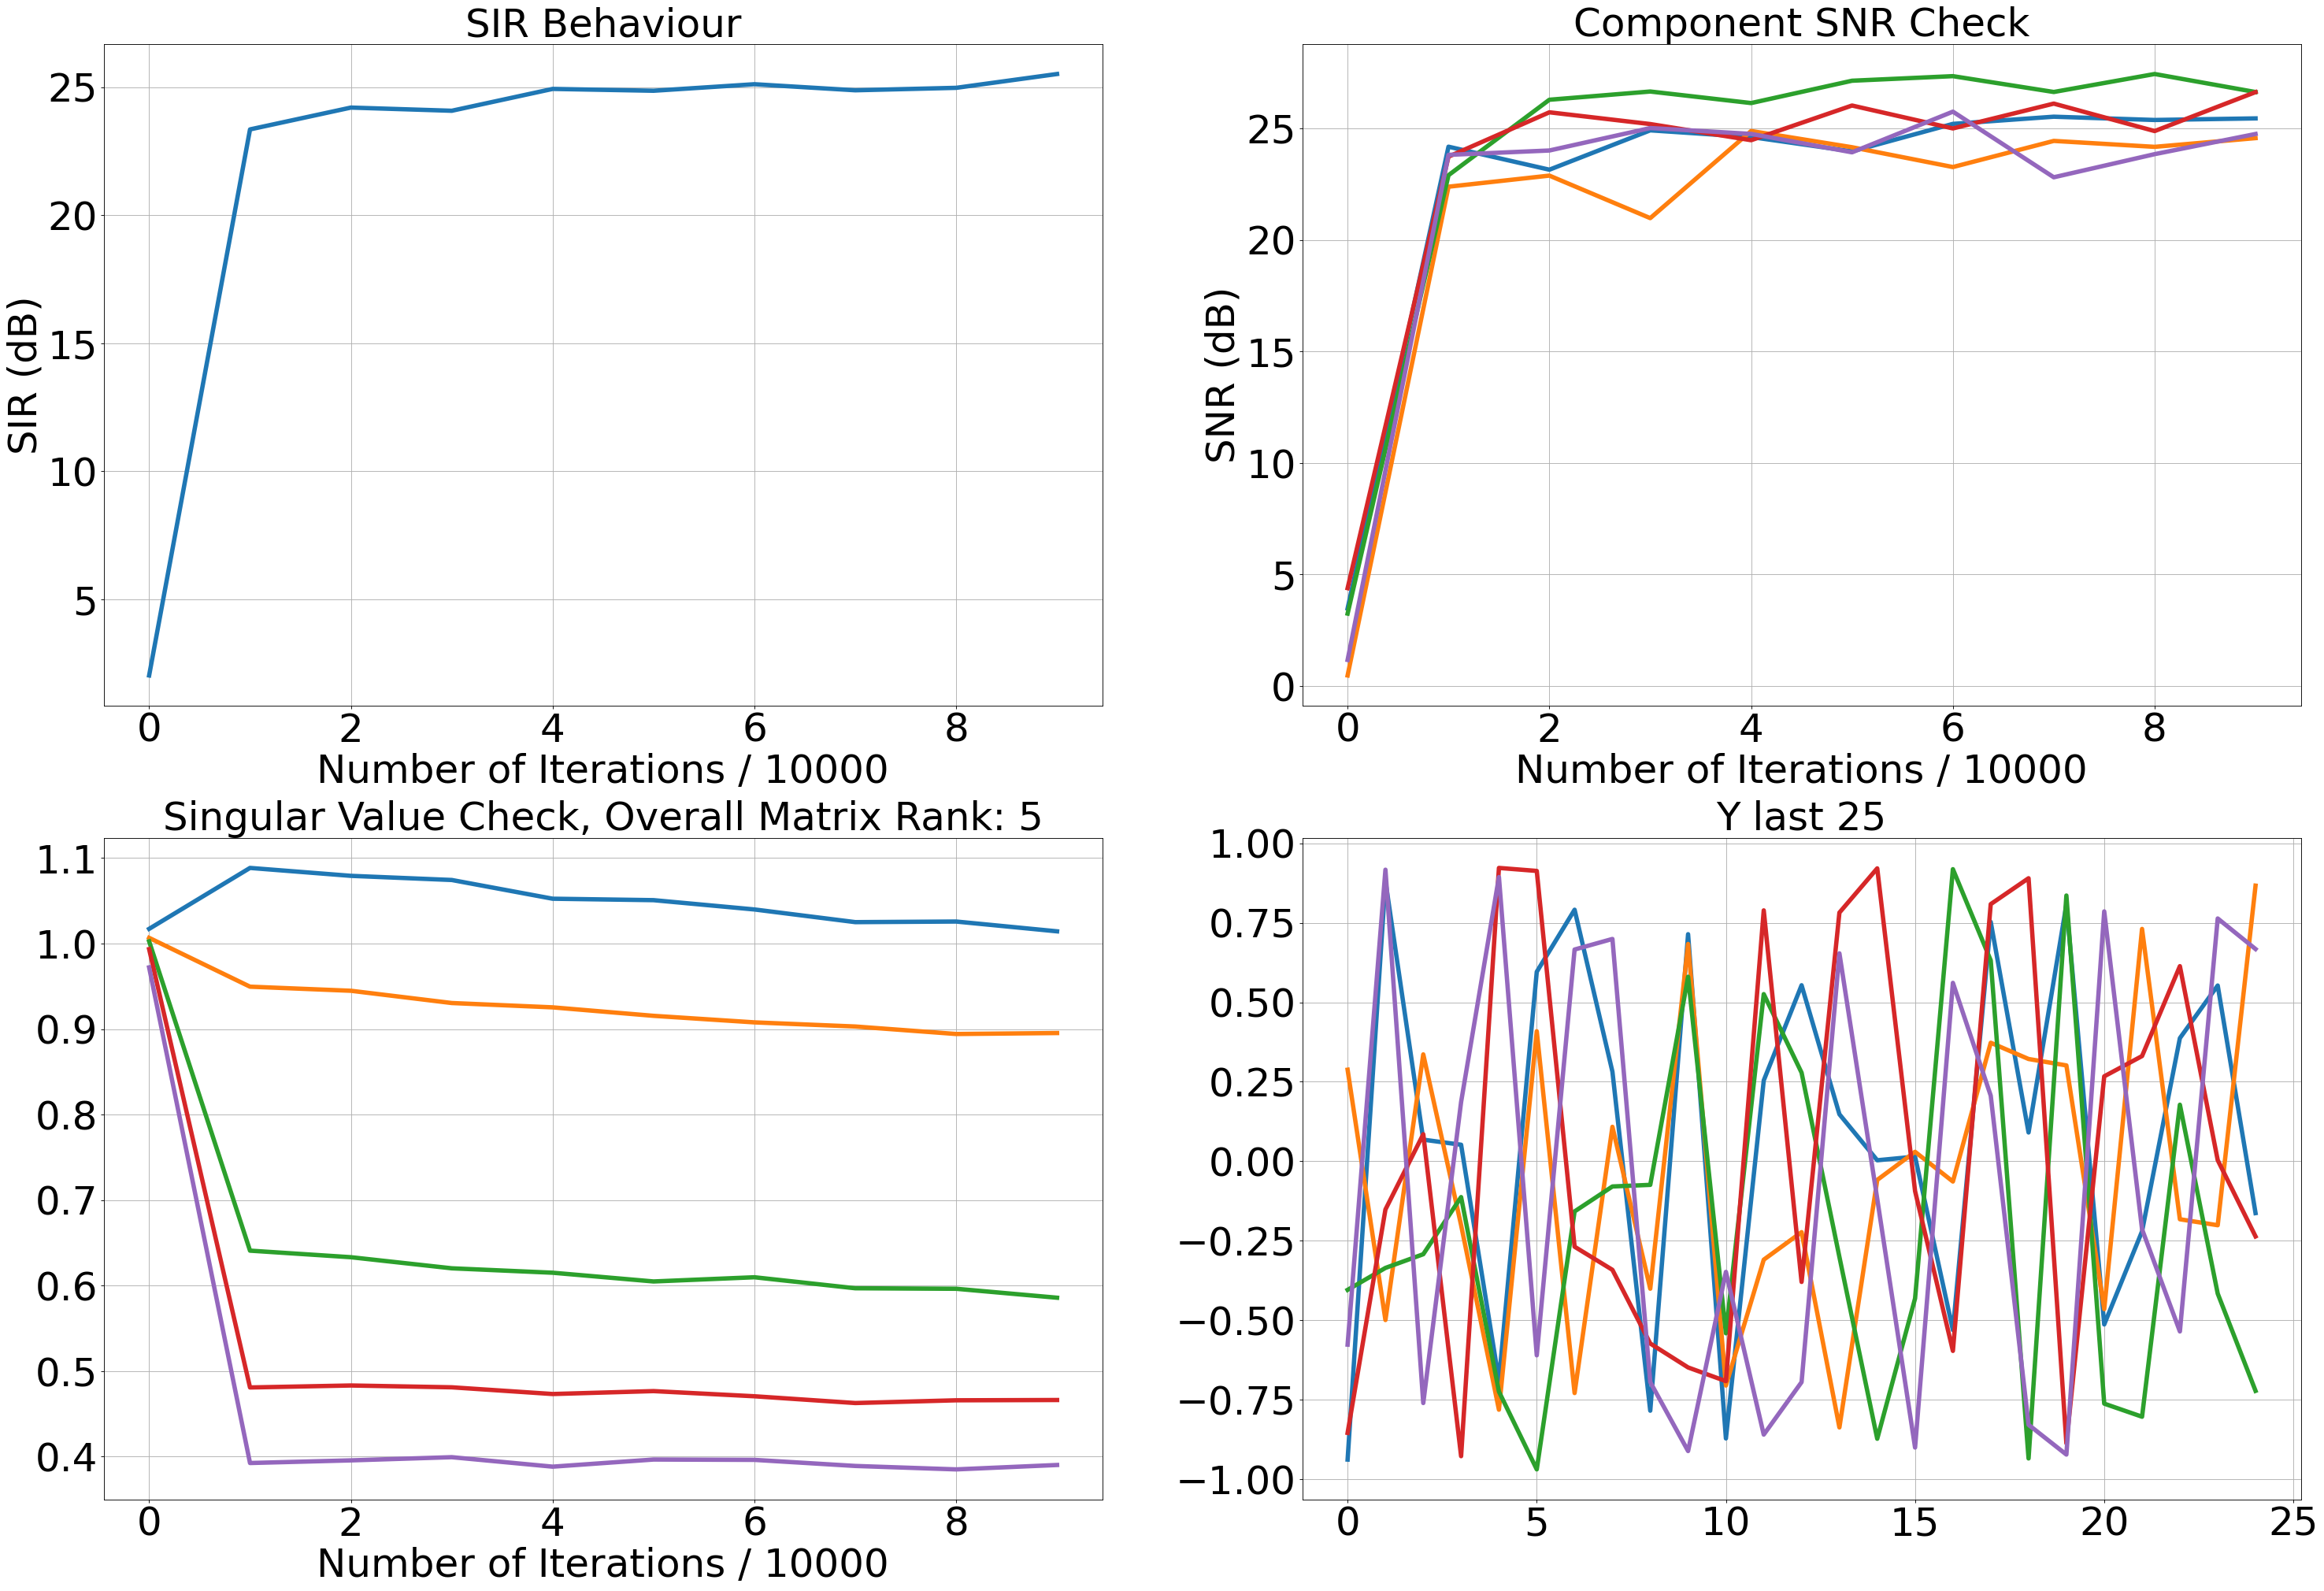

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "antisparse",
                ### Optimization parameters
                "lambda_lateral" : 0.999,
                "gamma_predictive" : 250,
                ### Learning rates 
                "lr_W" : 5 * 1e-2,
                "neural_lr_start" : 0.5,
                "neural_lr_stop" : 1e-6,
                "neural_dynamics_iterations" : 250,
                "neural_OUTPUT_COMP_TOL" : 1e-7,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_log_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrBSS(**hyperparam_dict)
model.fit(X)

In [4]:
display_matrix(model.C_y)

<IPython.core.display.Math object>

In [5]:
display_matrix(model.mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [6]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [7]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 25.612450241793372
Component Signal-to-Noise-Ratio (SNR) Values : [24.63781249 25.22257425 26.68995075 26.38219622 25.51218447]



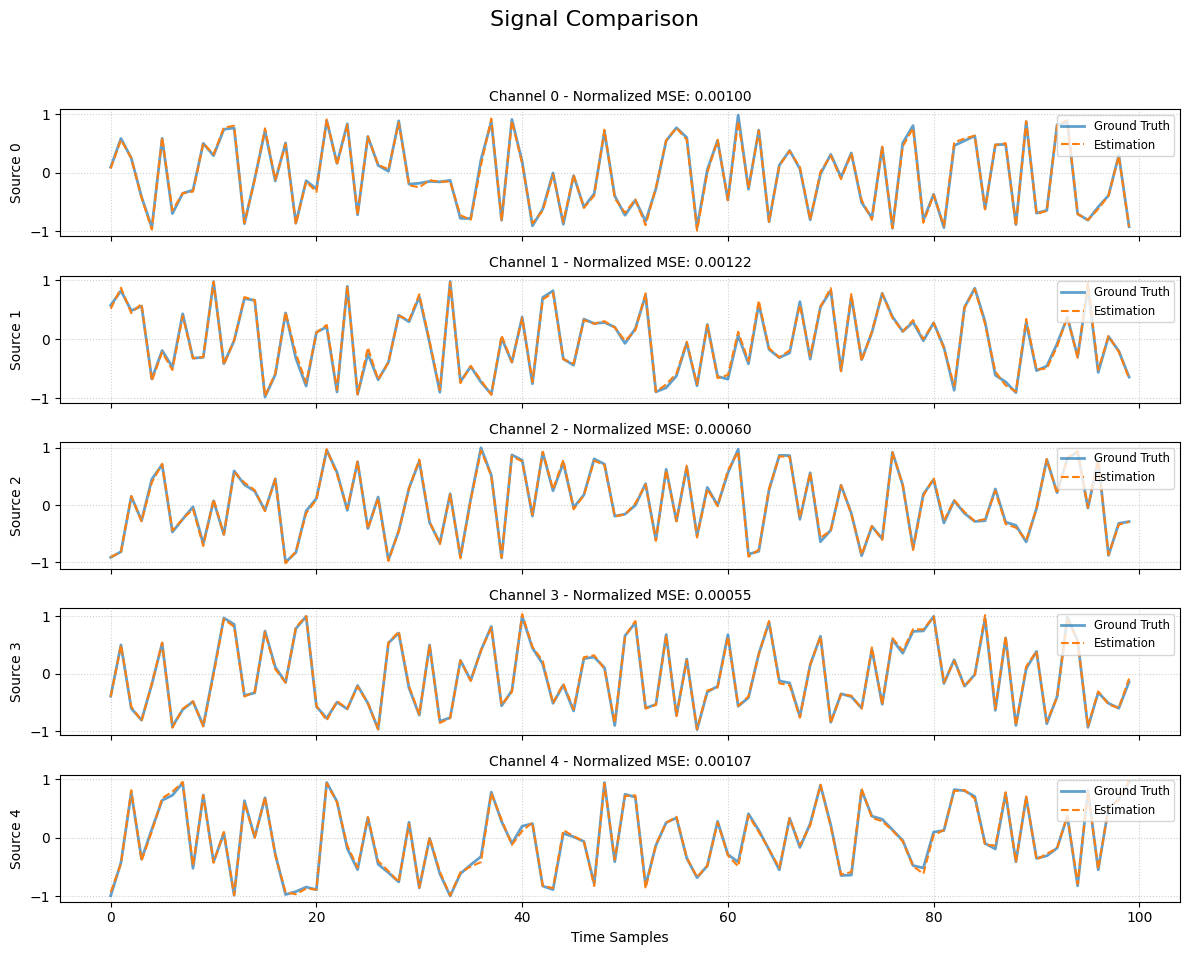

In [8]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])